## 📊 Índices financieros (muy usados en forecasting)

 - S&P 500 (^GSPC) → refleja la economía de EE.UU., buena para ver tendencias de largo plazo.
 - NASDAQ (^IXIC) → más volátil, útil para ver shocks (crisis puntocom, 2008, pandemia).
 - DAX (^GDAXI) → mercado europeo, interesante para comparar con EE.UU.
 - FTSE 100 (^FTSE) → Reino Unido, da contraste con otros mercados.
 - Nikkei 225 (^N225) → Japón, muestra comportamientos distintos (ej. crisis de los 90).

## 💹 Acciones individuales (más intuitivas para los estudiantes)

 - Apple (AAPL) → crecimiento sostenido, fácil de relacionar con productos que todos usan.
 - Tesla (TSLA) → alta volatilidad, sirve para ver cómo los modelos se comportan con ruido.
 - Coca-Cola (KO) → empresa estable, buena para ver series con menos variación.
 - Microsoft (MSFT) → larga historia, combinación de crecimiento + estabilidad.

## 📈 Series con estacionalidad marcada (para SARIMA)

 - Consumo de energía eléctrica (ej. demanda mensual de EE.UU., se puede bajar de EIA).
 - Ventas minoristas (RSXFS en FRED) → claro patrón navideño.
 - Pasajeros de aerolíneas (dataset clásico de Box & Jenkins: AirPassengers).

In [16]:
# pip install yfinance pandas openpyxl matplotlib statsmodels pmdarima

## 1. Proceso estocástico
Una **serie de tiempo** puede pensarse como una **realización de un proceso estocástico** \(\{X_t\}\).  

- Cada observación $(X_t)$ está asociada a un instante $t$ (ej. mes, trimestre, día).  
- El objetivo es **modelar la dependencia temporal**: cómo los valores pasados influyen en los presentes.

In [17]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

import numpy as np

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX



[*********************100%***********************]  10 of 10 completed


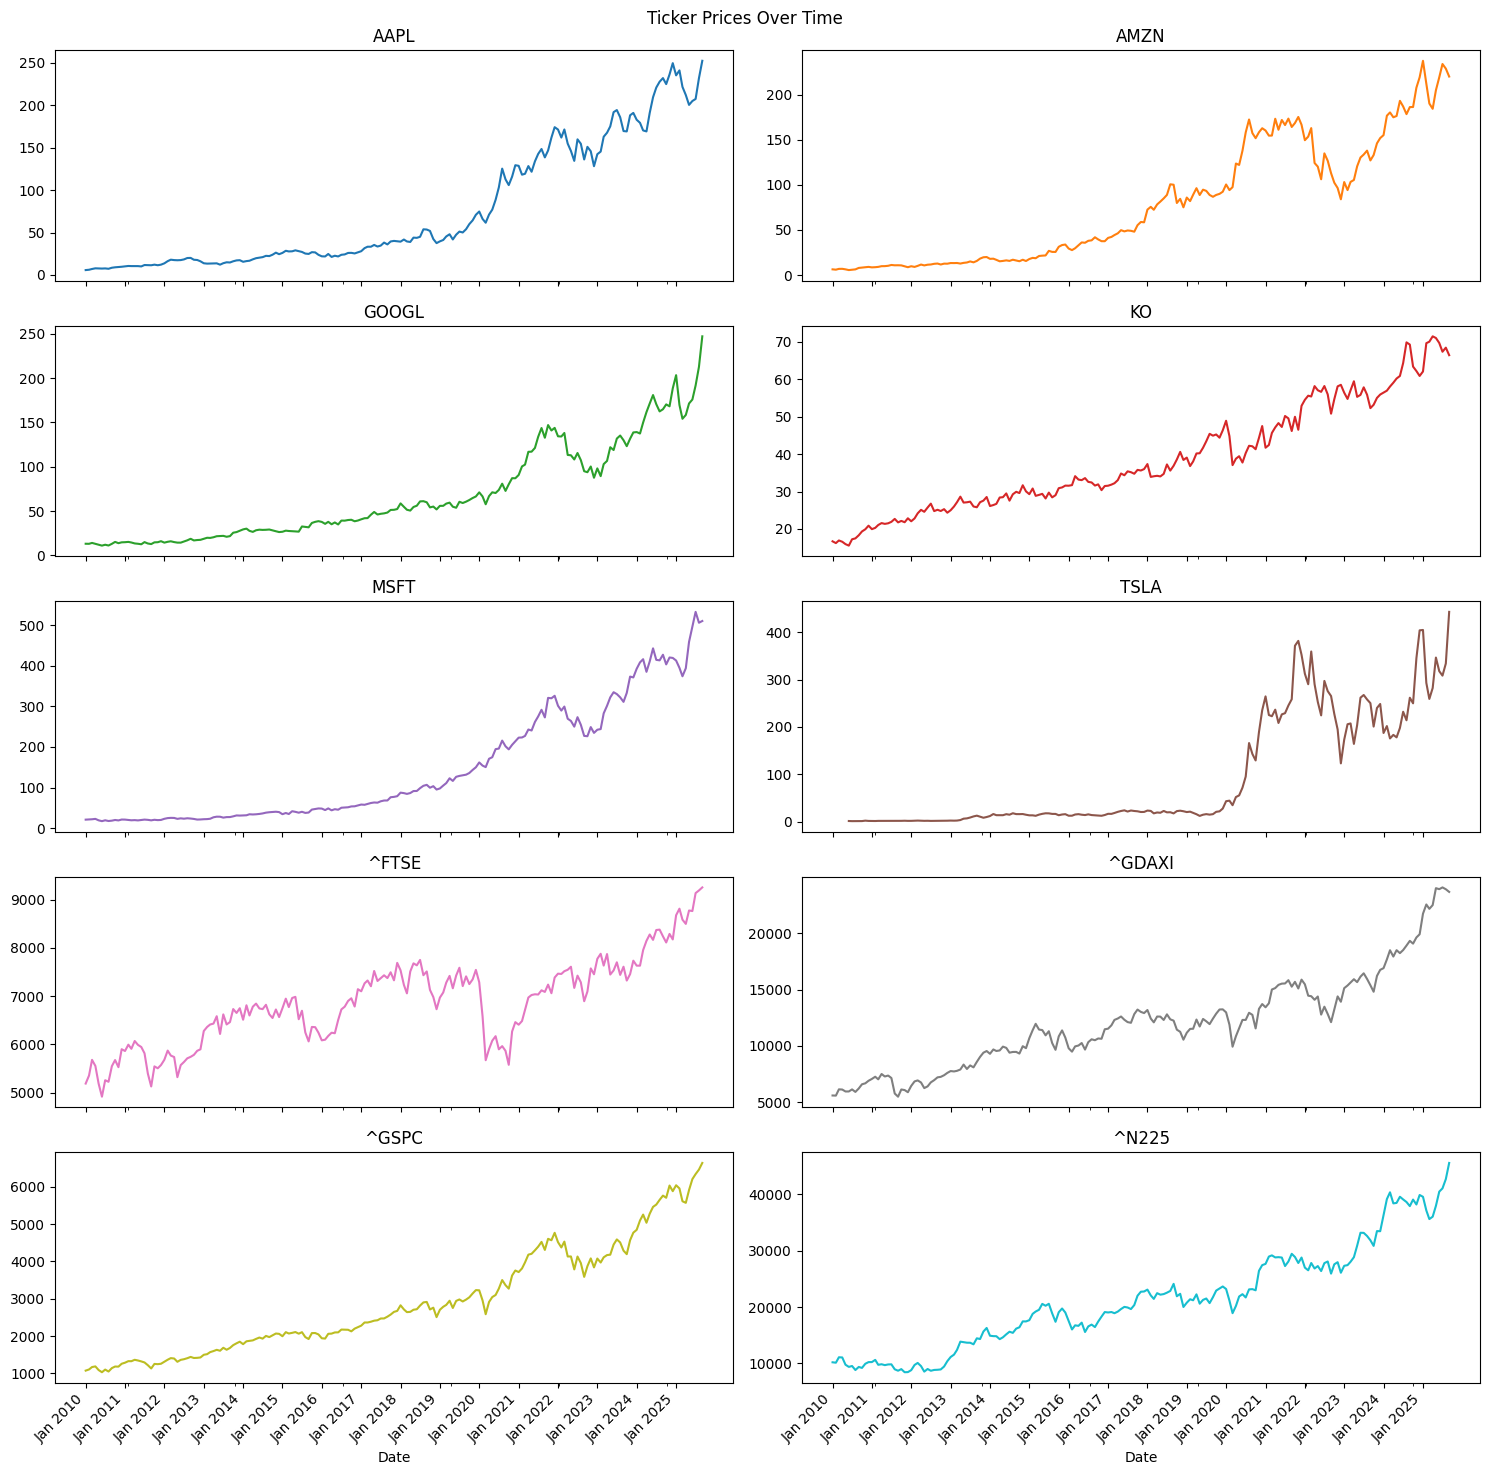

In [18]:

# Definir tickers
tickers = ["^GSPC", "^GDAXI", "^FTSE", "^N225", "AAPL", "KO", "MSFT", "TSLA", "AMZN", "GOOGL"]

# Descargar datos todos juntos
data = yf.download(tickers, start="2010-01-01", interval="1mo")["Close"]
data.plot(subplots=True, layout=(5, 2), figsize=(15, 15), legend=False, title="Ticker Prices Over Time", x_compat=True)

# Add titles to each subplot
for ax, ticker in zip(plt.gcf().get_axes(), data.columns):
    ax.set_title(ticker)
    ax.set_xlabel("Date")  # Add x-axis label as Date
    ax.set_xticks(data.index[::12])  # Show one tick per year (12 months interval)
    ax.set_xticklabels(data.index[::12].strftime('%b %Y'), rotation=45)  # Format as 'Month Year'
plt.tight_layout()

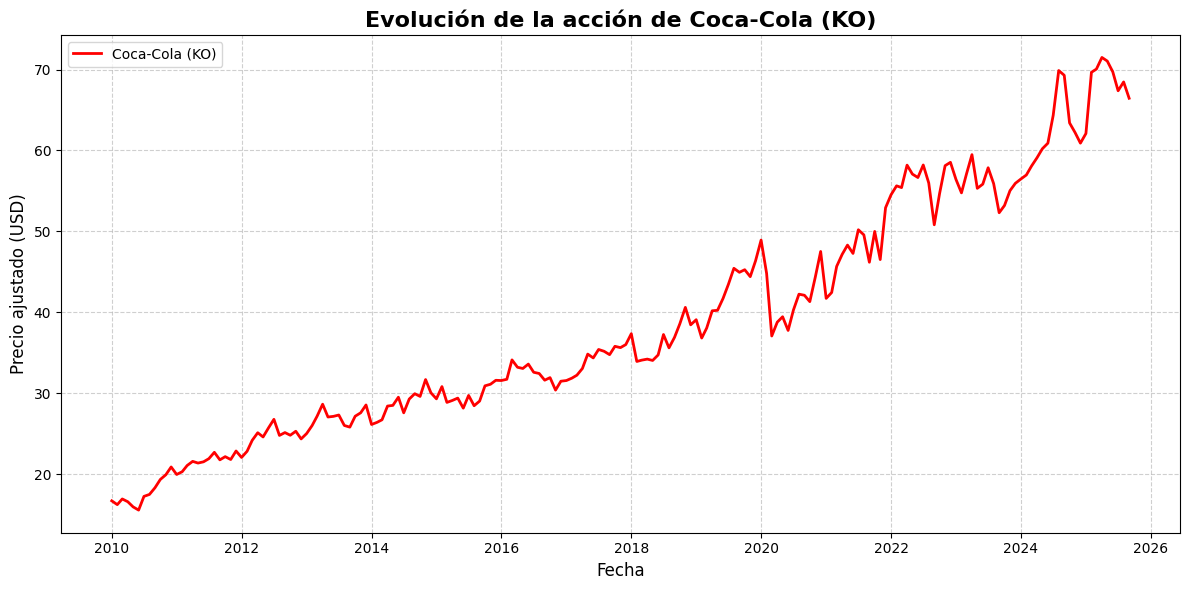

In [19]:
ko = data["KO"].dropna()
plt.figure(figsize=(12,6))
plt.plot(ko.index, ko.values, color="red", linewidth=2, label="Coca-Cola (KO)")

plt.title("Evolución de la acción de Coca-Cola (KO)", fontsize=16, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)    
plt.ylabel("Precio ajustado (USD)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


## 📊 Explicación técnica de la descomposición

Una serie de tiempo puede representarse bajo dos esquemas:

### 🔹 Modelo aditivo


$$X_t = T_t + S_t + R_t$$

- $(T_t)$: **tendencia** → cambio de largo plazo (ej. crecimiento estable de KO).  
- $(S_t)$: **estacionalidad** → patrones repetitivos cada 12 meses (ej. ventas más altas en verano).  
- $(R_t)$: **residuales** → variaciones no explicadas (ruido).  

---

### 🔹 Modelo multiplicativo

$$X_t = T_t \times S_t \times R_t$$

- Útil cuando la **variabilidad aumenta con el nivel de la serie**  
  (ej. cuando sube el precio, las oscilaciones también son mayores).

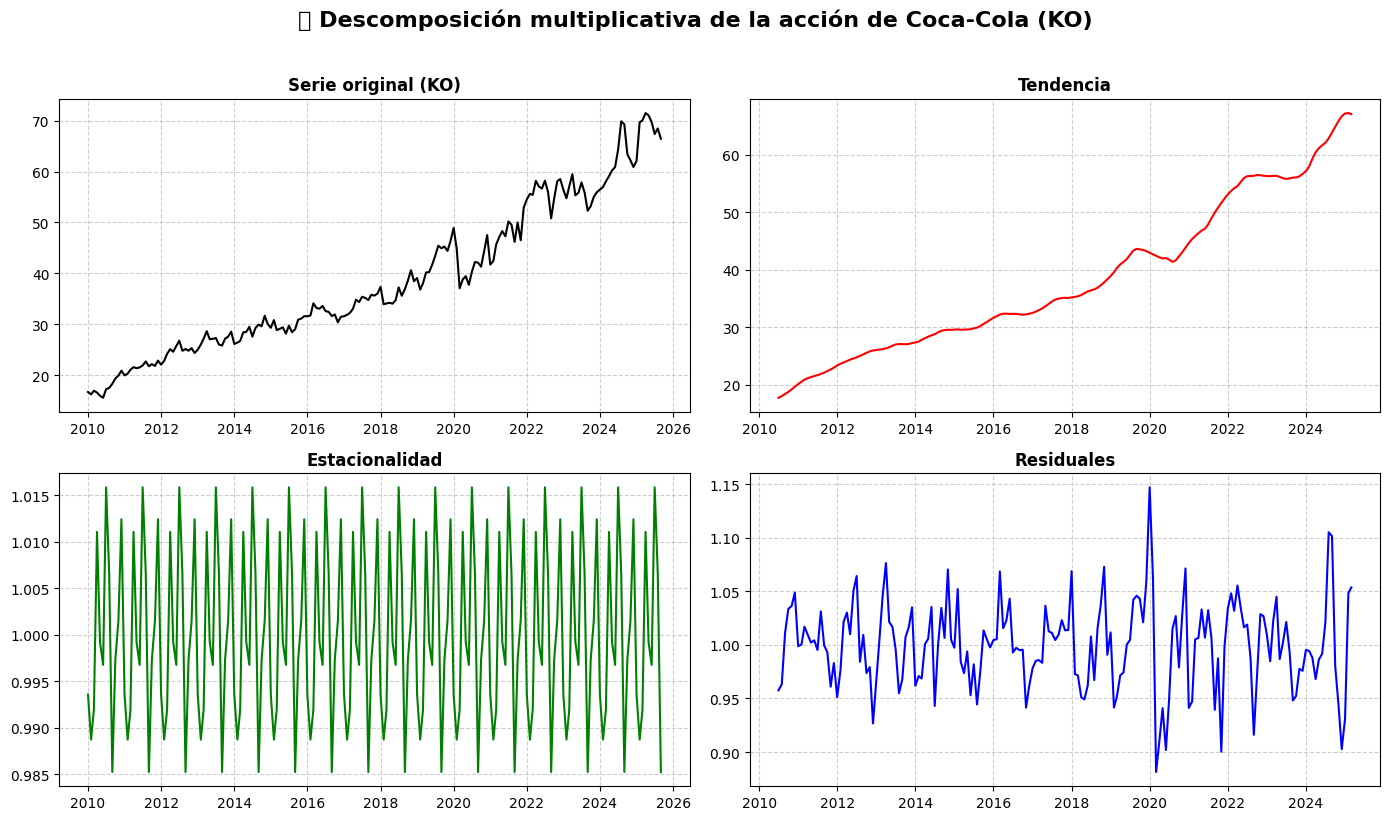

In [20]:
decomp = seasonal_decompose(ko, model="multiplicative", period=12)  

# Crear figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Serie original
axes[0,0].plot(ko, color="black")
axes[0,0].set_title("Serie original (KO)", fontsize=12, fontweight="bold")

# Tendencia
axes[0,1].plot(decomp.trend, color="red")
axes[0,1].set_title("Tendencia", fontsize=12, fontweight="bold")

# Estacionalidad
axes[1,0].plot(decomp.seasonal, color="green")
axes[1,0].set_title("Estacionalidad", fontsize=12, fontweight="bold")

# Residuales
axes[1,1].plot(decomp.resid, color="blue")
axes[1,1].set_title("Residuales", fontsize=12, fontweight="bold")

# Ajustes estéticos
for ax in axes.flat:
    ax.grid(True, linestyle="--", alpha=0.6)

plt.suptitle("📊 Descomposición multiplicativa de la acción de Coca-Cola (KO)", 
             fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

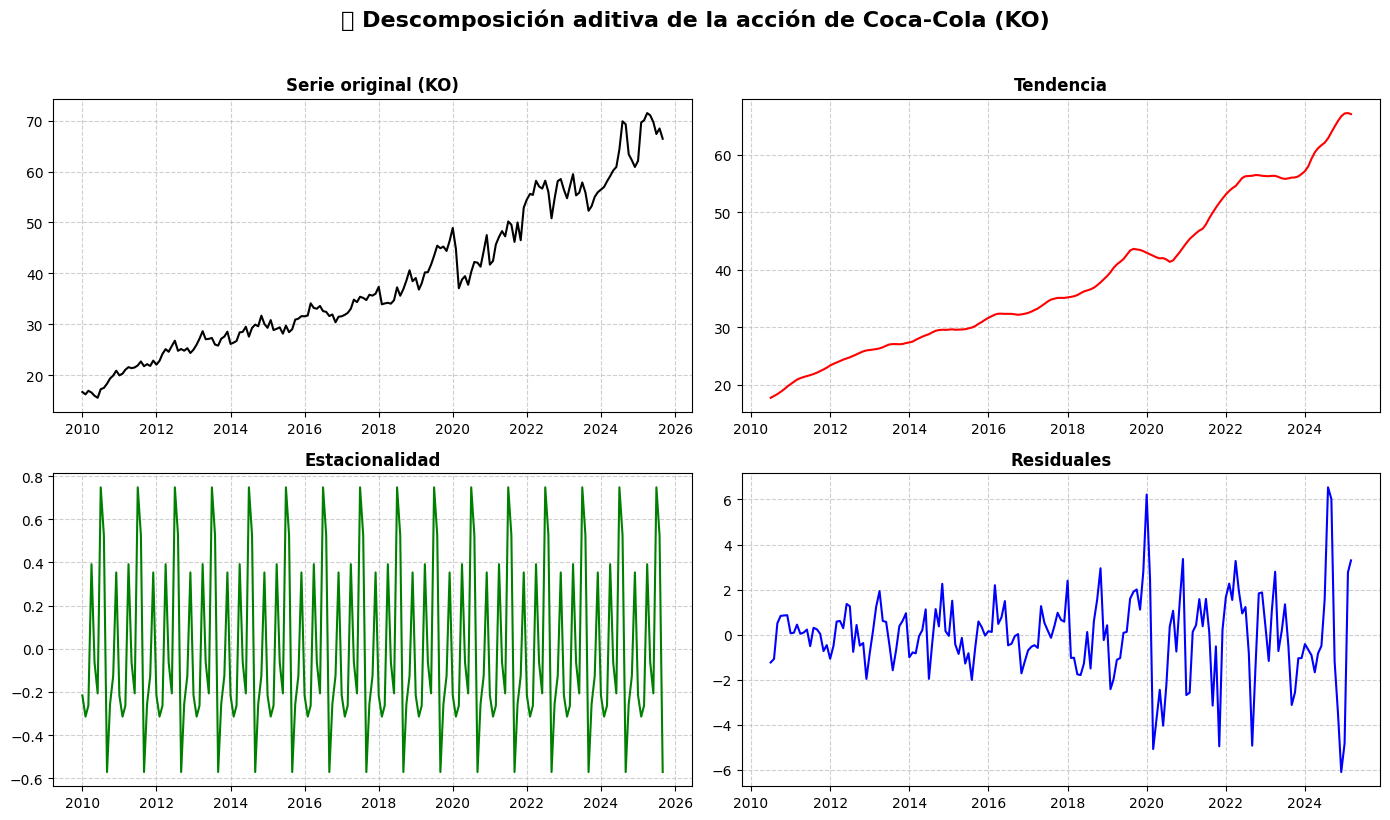

In [21]:
decomp = seasonal_decompose(ko, model="additive", period=12)  

# Crear figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Serie original
axes[0,0].plot(ko, color="black")
axes[0,0].set_title("Serie original (KO)", fontsize=12, fontweight="bold")

# Tendencia
axes[0,1].plot(decomp.trend, color="red")
axes[0,1].set_title("Tendencia", fontsize=12, fontweight="bold")

# Estacionalidad
axes[1,0].plot(decomp.seasonal, color="green")
axes[1,0].set_title("Estacionalidad", fontsize=12, fontweight="bold")

# Residuales
axes[1,1].plot(decomp.resid, color="blue")
axes[1,1].set_title("Residuales", fontsize=12, fontweight="bold")

# Ajustes estéticos
for ax in axes.flat:
    ax.grid(True, linestyle="--", alpha=0.6)

plt.suptitle("📊 Descomposición aditiva de la acción de Coca-Cola (KO)", 
             fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

# 📚 Fundamentos técnicos de los modelos de series de tiempo

## 2. Estacionariedad
Para aplicar modelos clásicos (AR, MA, ARMA), asumimos que la serie es **débilmente estacionaria**:

- Media constante:  
  $$
  \mathbb{E}[X_t] = \mu \quad \forall t
  $$

- Varianza constante:  
  $$
  \text{Var}(X_t) = \sigma^2 \quad \forall t
  $$

- Covarianza solo depende del rezago:  
  $$
  \text{Cov}(X_t, X_{t+k}) = \gamma_k
  $$

👉 En la práctica: si una serie no es estacionaria → **diferenciación** (ARIMA).



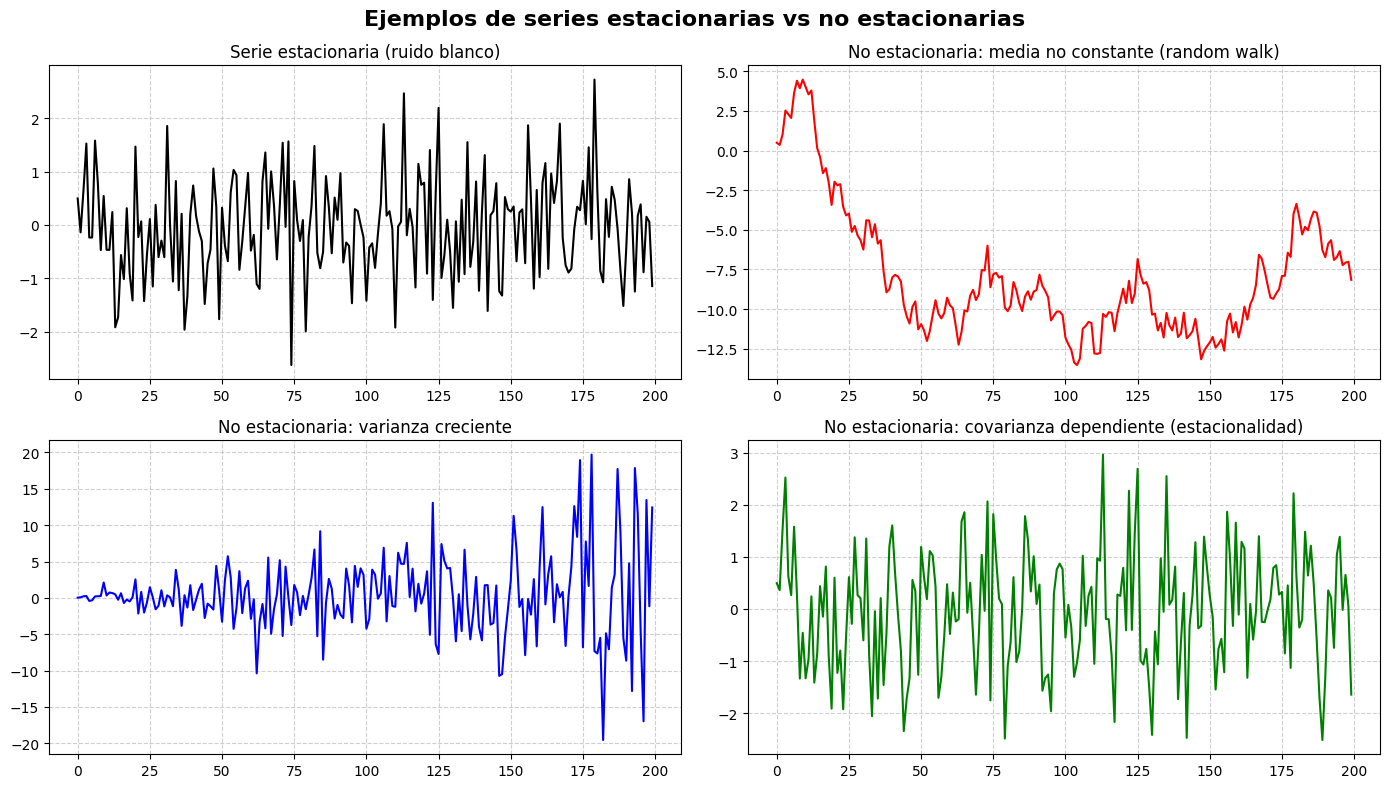

In [22]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # Reproducibilidad
n = 200
e = np.random.normal(0, 1, n)  # ruido blanco

# 1. Serie estacionaria (ruido blanco)
stationary = e

# 2. No estacionaria por media no constante (random walk)
non_stationary_mean = np.cumsum(e)

# 3. No estacionaria por varianza no constante (heterocedasticidad)
non_stationary_var = np.array([np.random.normal(0, i/20 + 0.1) for i in range(n)])

# 4. No estacionaria por covarianza dependiente del tiempo (estacionalidad)
t = np.arange(n)
seasonal = np.sin(2*np.pi*t/12) + e

# --- Graficar ---
fig, axes = plt.subplots(2, 2, figsize=(14,8))

axes[0,0].plot(stationary, color="black")
axes[0,0].set_title("Serie estacionaria (ruido blanco)", fontsize=12)

axes[0,1].plot(non_stationary_mean, color="red")
axes[0,1].set_title("No estacionaria: media no constante (random walk)", fontsize=12)

axes[1,0].plot(non_stationary_var, color="blue")
axes[1,0].set_title("No estacionaria: varianza creciente", fontsize=12)

axes[1,1].plot(seasonal, color="green")
axes[1,1].set_title("No estacionaria: covarianza dependiente (estacionalidad)", fontsize=12)

for ax in axes.flat:
    ax.grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Ejemplos de series estacionarias vs no estacionarias", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


### 📊 Evaluación de estacionariedad en la acción de Coca-Cola (KO)

En este ejemplo vamos a diagnosticar si la serie de Coca-Cola (KO) es estacionaria, evaluando:

1. Media constante (ADF / KPSS).  
2. Varianza constante (ARCH test).  
3. Covarianza dependiente solo del rezago (ACF/PACF).  
4. Residuales como ruido blanco (Ljung-Box).  

In [23]:
from statsmodels.tsa.stattools import adfuller, kpss

# Augmented Dickey-Fuller Test
adf_result = adfuller(ko)

print("ADF Test")
print("H0 = Serie no estacionaria")
print(f"Estadístico: {adf_result[0]:.4f}, p-value: {adf_result[1]:.4f}")

# KPSS Test
# kpss_result = kpss(ko, regression='c', nlags="auto")
# print("\nKPSS Test")
# print(f"Estadístico: {kpss_result[0]:.4f}, p-value: {kpss_result[1]:.4f}")

ADF Test
H0 = Serie no estacionaria
Estadístico: -0.1684, p-value: 0.9422


In [24]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(ko)
print("ARCH Test")
print("H0 = varianza constante")
print(f"Estadístico: {arch_test[0]:.4f}, p-value: {arch_test[1]:.4f}")

ARCH Test
H0 = varianza constante
Estadístico: 174.9023, p-value: 0.0000


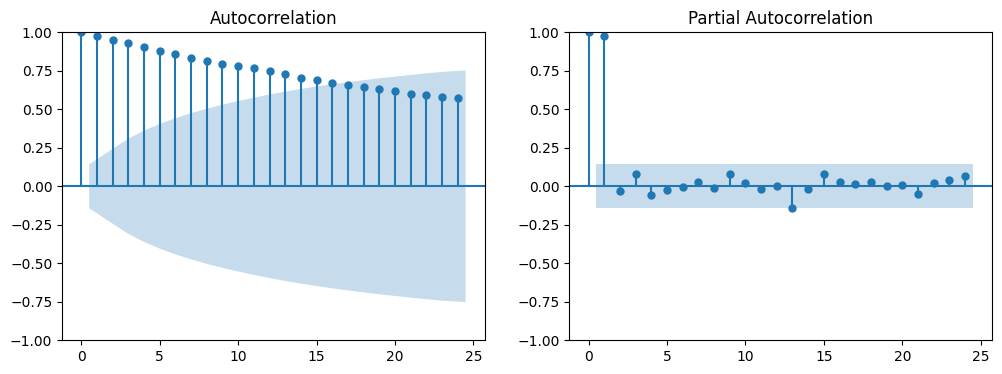

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(ko, lags=24, ax=axes[0])
plot_pacf(ko, lags=24, ax=axes[1])
plt.show()

👉 Interpretación:
Patrones en ACF/PACF indican dependencia temporal o estacionalidad.

In [26]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box test sobre la serie original
print("H0: no hay autocorrelación (residuales ~ ruido blanco).")
ljung = acorr_ljungbox(ko, lags=[12], return_df=True)
print(ljung)

H0: no hay autocorrelación (residuales ~ ruido blanco).
        lb_stat  lb_pvalue
12  1734.953172        0.0


# 🔧 Estrategias frente a la no estacionariedad en series de tiempo

Cuando una serie de tiempo **viola los supuestos de estacionariedad**, debemos aplicar transformaciones o técnicas específicas según el problema detectado.  

---

## 1. Media no constante (tendencia)
**Síntoma:** la serie muestra un crecimiento o decrecimiento sistemático (ej. random walk).  

**Estrategias:**
- Aplicar **diferenciación**:  
  $$
  Y'_t = X_t - X_{t-1}
  $$
- Usar **modelos ARIMA** con parámetro $d > 0$.  
- Incluir **términos deterministas** (tendencia lineal o cuadrática).  

---

## 2. Varianza no constante (heterocedasticidad)
**Síntoma:** la variabilidad aumenta o disminuye con el tiempo.  

**Estrategias:**
- Aplicar **transformaciones estabilizadoras**:  
  - Logaritmo: $Y_t = \log(X_t)$  
  - Raíz cuadrada: $Y_t = \sqrt{X_t}$
  - Box-Cox: transformación paramétrica.  
- Usar **modelos GARCH/ARCH** para series financieras donde la volatilidad es importante.  

---

## 3. Covarianza dependiente del tiempo (estacionalidad)
**Síntoma:** aparecen patrones que se repiten en ciclos (ej. consumo eléctrico mensual, ventas en diciembre).  

**Estrategias:**
- Aplicar **diferenciación estacional**:  
  $$
  Y'_t = X_t - X_{t-s}
  $$
  donde $s$ es la periodicidad (ej. 12 para datos mensuales).  
- Usar **modelos SARIMA** $(p,d,q)(P,D,Q)_s$.  
- Incluir **variables dummy estacionales** en modelos de regresión.  

---

## 4. Ruido no blanco en los residuales
**Síntoma:** los errores del modelo muestran correlación (no parecen aleatorios).  

**Estrategias:**
- Reajustar el orden $p$ y $q$ usando ACF/PACF.  
- Usar criterios de selección de modelos (AIC, BIC) para encontrar un modelo más parsimonioso.  
- Aplicar pruebas de diagnóstico (ej. **Ljung-Box**) para verificar independencia.  

---

# ✅ Conclusión
- **Primero diagnosticamos** con gráficos y pruebas (ACF, PACF, test de Dickey-Fuller, Ljung-Box, etc.).  
- **Luego aplicamos la estrategia adecuada** según la violación:  
  - Tendencia → diferenciación.  
  - Varianza → transformaciones o GARCH.  
  - Estacionalidad → diferenciación estacional o SARIMA.  
  - Residuales → ajustar orden del modelo.  


In [27]:
def test_stationarity(series, name="Serie"):
    """Ejecuta ADF y KPSS y muestra resultados resumidos"""
    adf = adfuller(series.dropna())
    arch_test = het_arch(series)
    ljung = acorr_ljungbox(ko, lags=[12], return_df=True)


    print(f"ADF: estadístico={adf[0]:.4f}, p-value={adf[1]:.4f}")
    print(f"ARCH: Estadístico: {arch_test[0]:.4f}, p-value: {arch_test[1]:.4f}")
    print(f"ljung-box: \n{ljung}")

# Serie original
print("Series original")
test_stationarity(ko, "KO original")

# 1. Transformación logarítmica (estabiliza varianza)
ko_log = np.log(ko)
print("Series logaritmo")
test_stationarity(ko_log, "KO log")

# 2. Primera diferenciación (remueve tendencia en media)
ko_log_diff = ko_log.diff().dropna()
print("Series logaritmo y diferenciada")
test_stationarity(ko_log_diff, "KO log + diff(1)")

Series original
ADF: estadístico=-0.1684, p-value=0.9422
ARCH: Estadístico: 174.9023, p-value: 0.0000
ljung-box: 
        lb_stat  lb_pvalue
12  1734.953172        0.0
Series logaritmo
ADF: estadístico=-1.2364, p-value=0.6577
ARCH: Estadístico: 176.1927, p-value: 0.0000
ljung-box: 
        lb_stat  lb_pvalue
12  1734.953172        0.0
Series logaritmo y diferenciada
ADF: estadístico=-12.1691, p-value=0.0000
ARCH: Estadístico: 12.7046, p-value: 0.2407
ljung-box: 
        lb_stat  lb_pvalue
12  1734.953172        0.0


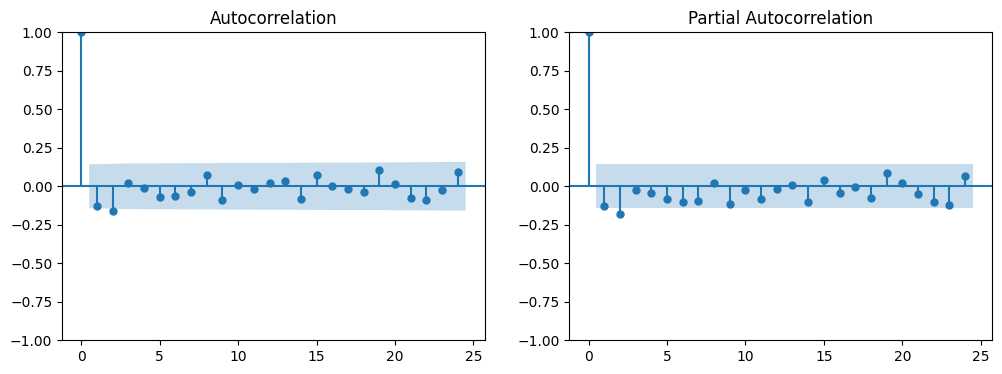

In [28]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(ko_log_diff, lags=24, ax=axes[0])
plot_pacf(ko_log_diff, lags=24, ax=axes[1])
plt.show()

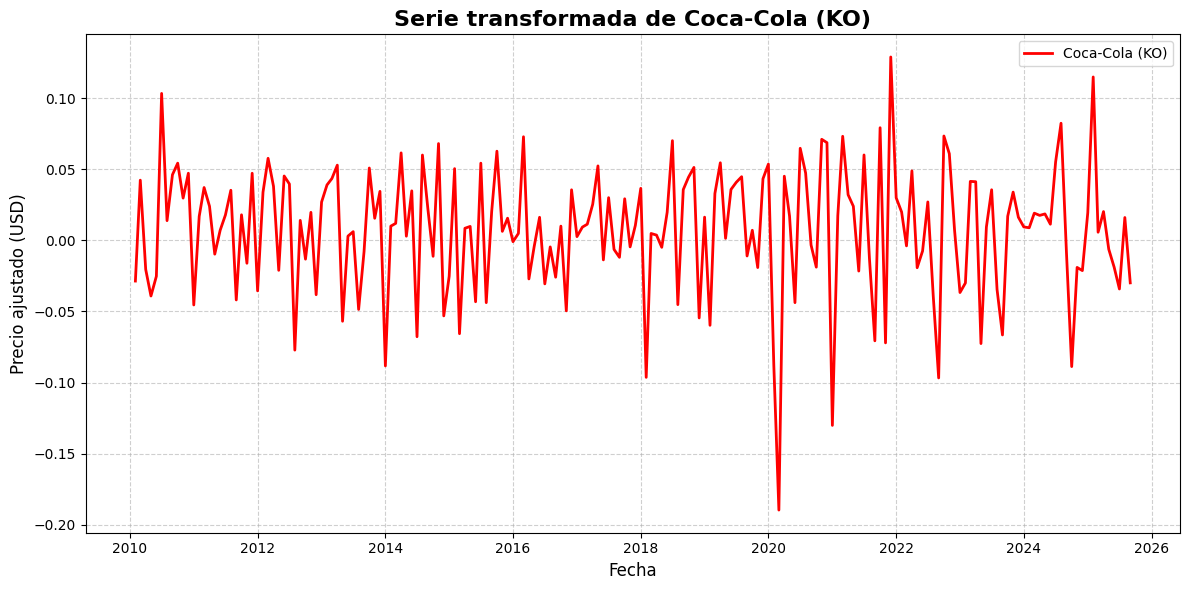

In [29]:
plt.figure(figsize=(12,6))
plt.plot(ko_log_diff.index, ko_log_diff.values, color="red", linewidth=2, label="Coca-Cola (KO)")

plt.title("Serie transformada de Coca-Cola (KO)", fontsize=16, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)    
plt.ylabel("Precio ajustado (USD)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Modelo AR (Autoregresivo)
Depende de sus propios rezagos:  

$$
X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \dots + \phi_p X_{t-p} + \varepsilon_t
$$

- $\varepsilon_t \sim \text{ruido blanco}$  
- $p$: orden del modelo  

**Intuición:** lo que pasa hoy depende de lo que pasó en los últimos \(p\) periodos.  

---

## 5. Modelo MA (Media móvil)
Depende de los **errores pasados**:  

$$
X_t = \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}
$$

- $q$: orden del modelo  

**Intuición:** el valor actual es una media ponderada de errores recientes.

---

## 6. Modelo ARMA
Combinación de AR(p) y MA(q):  

$$
X_t = \phi_1 X_{t-1} + \dots + \phi_p X_{t-p} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}
$$

Adecuado para **series estacionarias** que muestran tanto autocorrelación como dependencia de errores.

---

## 7. Modelo ARIMA
Incluye diferenciación para manejar series **no estacionarias**:  

$$
\nabla^d X_t = (1-B)^d X_t
$$

donde $B$ es el operador de rezago.  

- Notación: **ARIMA(p, d, q)**  
  - $p$: rezagos autoregresivos  
  - $d$: número de diferenciaciones  
  - $q$: rezagos de media móvil  

👉 Muy usado en **series financieras y económicas**.

---

## 8. Modelo SARIMA (estacional)
Extiende ARIMA para incluir **componentes estacionales**:  

$$
SARIMA(p,d,q)(P,D,Q)_s
$$

- $s$: periodicidad estacional (ej. 12 para mensual, 4 para trimestral).  
- $P, D, Q$: órdenes de los componentes estacionales.  

**Ejemplo:** ventas de bebidas que se repiten cada verano.


# Identificación del modelo

Cuando construimos un modelo ARIMA, tenemos que considerar la $p$, $d$ y $q$ que entran en nuestro modelo ARIMA. 

El primer parámetro, p, es el número de observaciones retardadas. Al considerar  p, determinamos efectivamente cuánto nos remontamos en el tiempo al intentar predecir la observación actual. Para ello, nos fijamos en las autocorrelaciones de nuestras series temporales, que son las correlaciones de nuestras series en los retardos temporales anteriores. 
El segundo parámetro, d, se refiere al orden de diferenciación. Diferenciar significa simplemente encontrar las diferencias entre pasos temporales consecutivos. Es una forma de hacer que nuestros datos sean estacionarios, lo que significa eliminar las tendencias o la estacionalidad.  d indica la diferenciación en qué orden se obtiene un proceso estacionario.
El tercer parámetro q se refiere al orden de la parte de media móvil (MA) del modelo. Representa el número de errores de previsión retardados incluidos en el modelo. A diferencia de una media móvil simple, que suaviza los datos, la media móvil en ARIMA capta la relación entre una observación y los errores residuales de un modelo de media móvil aplicado a observaciones retardadas.

# Fase de modelamiento

## Modelo $AR(p)$

Según el análisis del Autocrrelograma en la sección anterior, la cantidad de rezagos que se salen en la gráfica pertenecen al valor de 2. 

Lo que nos hace pensar que podemos ajustar un modelo $AR(2)$

In [30]:
# ======================
# 2. Modelo AR (autoregresivo puro)
# ======================
model_ar = ARIMA(ko_log_diff, order=(2,0,0))  # AR(2)
result_ar = model_ar.fit()
print(result_ar.summary())


                               SARIMAX Results                                
Dep. Variable:                     KO   No. Observations:                  188
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 321.340
Date:                Wed, 24 Sep 2025   AIC                           -634.681
Time:                        19:22:01   BIC                           -621.735
Sample:                    02-01-2010   HQIC                          -629.436
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0074      0.003      2.858      0.004       0.002       0.012
ar.L1         -0.1534      0.068     -2.241      0.025      -0.288      -0.019
ar.L2         -0.1784      0.078     -2.280      0.0

In [31]:
# ======================
# 3. Predicciones en escala diferenciada (log diff)
# ======================
n_forecast = 24  # pronósticos a 24 meses
forecast_diff = result_ar.get_forecast(steps=n_forecast)
forecast_diff_mean = forecast_diff.predicted_mean
forecast_diff_ci = forecast_diff.conf_int()
forecast_diff_mean

2025-10-01    0.011583
2025-11-01    0.013419
2025-12-01    0.005743
2026-01-01    0.006593
2026-02-01    0.007832
2026-03-01    0.007490
2026-04-01    0.007321
2026-05-01    0.007408
2026-06-01    0.007425
2026-07-01    0.007407
2026-08-01    0.007407
2026-09-01    0.007410
2026-10-01    0.007409
2026-11-01    0.007409
2026-12-01    0.007409
2027-01-01    0.007409
2027-02-01    0.007409
2027-03-01    0.007409
2027-04-01    0.007409
2027-05-01    0.007409
2027-06-01    0.007409
2027-07-01    0.007409
2027-08-01    0.007409
2027-09-01    0.007409
Freq: MS, Name: predicted_mean, dtype: float64

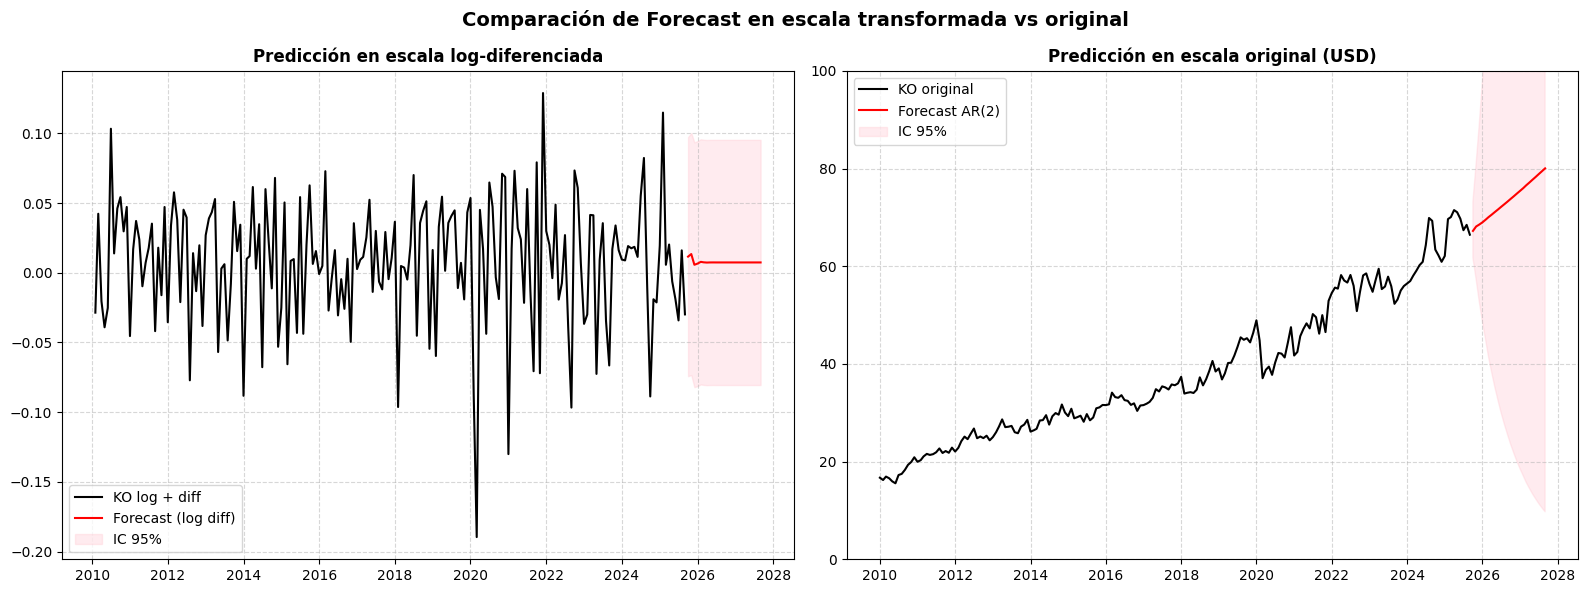

In [32]:
# ======================
# 4. Reconstrucción: de diff(log) → log → original
# ======================
last_log_value = ko_log.iloc[-1]  # último valor en log
forecast_log = forecast_diff_mean.cumsum() + last_log_value
forecast_original = np.exp(forecast_log)

forecast_log_ci = forecast_diff_ci.cumsum() + last_log_value
forecast_original_ci = np.exp(forecast_log_ci)

# ======================
# 5. Gráficos comparativos
# ======================
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# (a) Serie transformada: log + diff
axes[0].plot(ko_log_diff, label="KO log + diff", color="black")
axes[0].plot(forecast_diff_mean, label="Forecast (log diff)", color="red")
axes[0].fill_between(forecast_diff_ci.index, 
                     forecast_diff_ci.iloc[:,0], forecast_diff_ci.iloc[:,1],
                     color="pink", alpha=0.3, label="IC 95%")
axes[0].set_title("Predicción en escala log-diferenciada", fontsize=12, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# (b) Serie original
axes[1].plot(ko, label="KO original", color="black")
axes[1].plot(forecast_original, label="Forecast AR(2)", color="red")
axes[1].fill_between(forecast_original_ci.index, 
                     forecast_original_ci.iloc[:,0], forecast_original_ci.iloc[:,1],
                     color="pink", alpha=0.3, label="IC 95%")
axes[1].set_title("Predicción en escala original (USD)", fontsize=12, fontweight="bold")
axes[1].set_ylim(0, 100)  # 👈 recortar eje Y a máximo 100
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

plt.suptitle("Comparación de Forecast en escala transformada vs original", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Modelo $MA(q)$

Para el modelo $MA$ el análisis es similar, pero esta vez nos detenemos en el autocorrelograma parcial, donde igualmente vemos dos rezago por fuera de la bandas de confianza, lo que nos lleva a pensar que podríamos ajustar un modelo $MA(2)$ 

In [33]:
# ======================
# 3. Modelo MA (media móvil puro)
# ======================
model_ma = ARIMA(ko_log_diff, order=(0,0,2))  # MA(2)
result_ma = model_ma.fit()
print(result_ma.summary())


                               SARIMAX Results                                
Dep. Variable:                     KO   No. Observations:                  188
Model:                 ARIMA(0, 0, 2)   Log Likelihood                 322.075
Date:                Wed, 24 Sep 2025   AIC                           -636.150
Time:                        19:22:01   BIC                           -623.204
Sample:                    02-01-2010   HQIC                          -630.905
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0075      0.002      3.491      0.000       0.003       0.012
ma.L1         -0.1765      0.068     -2.613      0.009      -0.309      -0.044
ma.L2         -0.1998      0.075     -2.672      0.0

In [34]:
# ======================
# 3. Predicciones en escala diferenciada (log diff)
# ======================
n_forecast = 24  # pronósticos a 24 meses
forecast_diff = result_ma.get_forecast(steps=n_forecast)
forecast_diff_mean = forecast_diff.predicted_mean
forecast_diff_ci = forecast_diff.conf_int()
forecast_diff_mean

2025-10-01    0.016560
2025-11-01    0.016933
2025-12-01    0.007492
2026-01-01    0.007492
2026-02-01    0.007492
2026-03-01    0.007492
2026-04-01    0.007492
2026-05-01    0.007492
2026-06-01    0.007492
2026-07-01    0.007492
2026-08-01    0.007492
2026-09-01    0.007492
2026-10-01    0.007492
2026-11-01    0.007492
2026-12-01    0.007492
2027-01-01    0.007492
2027-02-01    0.007492
2027-03-01    0.007492
2027-04-01    0.007492
2027-05-01    0.007492
2027-06-01    0.007492
2027-07-01    0.007492
2027-08-01    0.007492
2027-09-01    0.007492
Freq: MS, Name: predicted_mean, dtype: float64

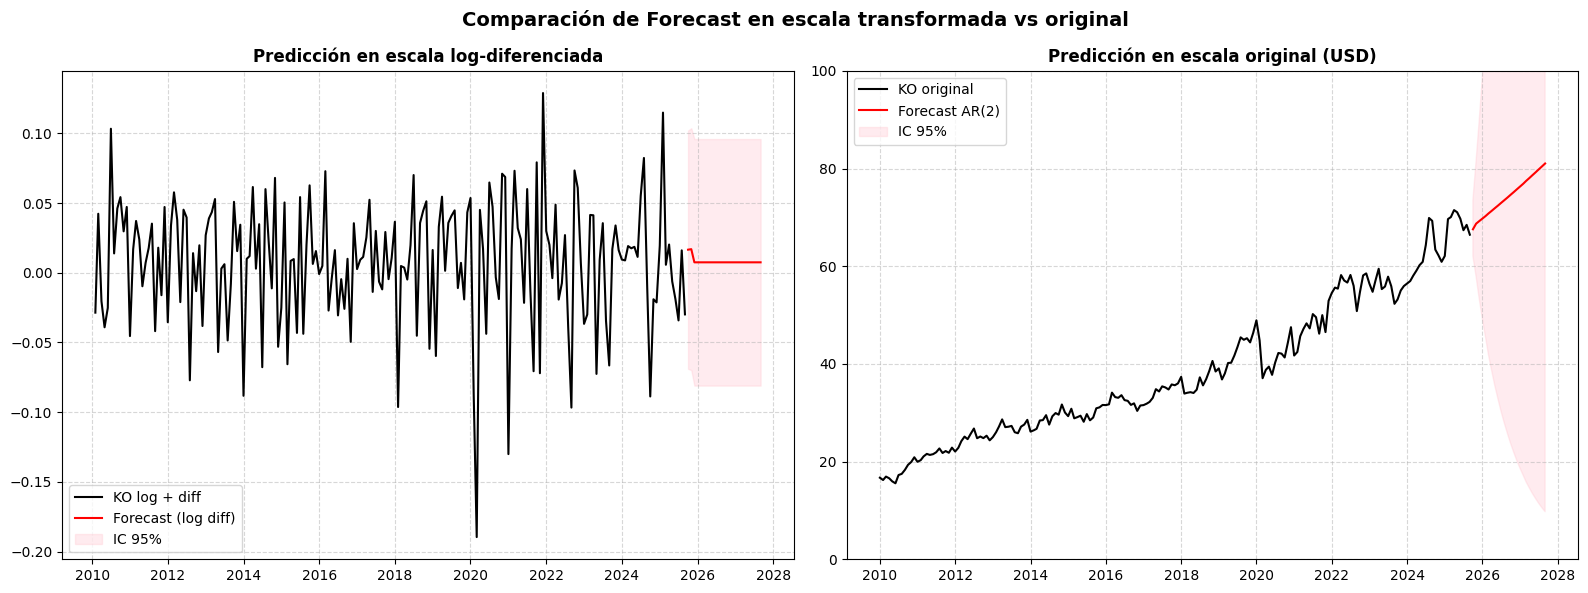

In [35]:
# ======================
# 4. Reconstrucción: de diff(log) → log → original
# ======================
last_log_value = ko_log.iloc[-1]  # último valor en log
forecast_log = forecast_diff_mean.cumsum() + last_log_value
forecast_original = np.exp(forecast_log)

forecast_log_ci = forecast_diff_ci.cumsum() + last_log_value
forecast_original_ci = np.exp(forecast_log_ci)

# ======================
# 5. Gráficos comparativos
# ======================
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# (a) Serie transformada: log + diff
axes[0].plot(ko_log_diff, label="KO log + diff", color="black")
axes[0].plot(forecast_diff_mean, label="Forecast (log diff)", color="red")
axes[0].fill_between(forecast_diff_ci.index, 
                     forecast_diff_ci.iloc[:,0], forecast_diff_ci.iloc[:,1],
                     color="pink", alpha=0.3, label="IC 95%")
axes[0].set_title("Predicción en escala log-diferenciada", fontsize=12, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# (b) Serie original
axes[1].plot(ko, label="KO original", color="black")
axes[1].plot(forecast_original, label="Forecast AR(2)", color="red")
axes[1].fill_between(forecast_original_ci.index, 
                     forecast_original_ci.iloc[:,0], forecast_original_ci.iloc[:,1],
                     color="pink", alpha=0.3, label="IC 95%")
axes[1].set_title("Predicción en escala original (USD)", fontsize=12, fontweight="bold")
axes[1].set_ylim(0, 100)  # 👈 recortar eje Y a máximo 100
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

plt.suptitle("Comparación de Forecast en escala transformada vs original", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Modelo $ARMA(p,q)$

Podríamos pensar entonces en hacer una combinación de los dos modelos $AR(2)$ y $MA(2)$, y por lo tanto podríamos ajustar un modelo $ARMA(2,2)$

In [36]:
# ======================
# 4. Modelo ARMA (AR+MA)
# ======================
model_arma = ARIMA(ko_log_diff, order=(1,0,1))  # ARMA(2,2)
result_arma = model_arma.fit()
print(result_arma.summary())


                               SARIMAX Results                                
Dep. Variable:                     KO   No. Observations:                  188
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 325.126
Date:                Wed, 24 Sep 2025   AIC                           -642.251
Time:                        19:22:02   BIC                           -629.305
Sample:                    02-01-2010   HQIC                          -637.006
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0069      0.000     22.845      0.000       0.006       0.007
ar.L1          0.7954      0.066     12.035      0.000       0.666       0.925
ma.L1         -0.9998      2.577     -0.388      0.6

In [37]:
# ======================
# 3. Predicciones en escala diferenciada (log diff)
# ======================
n_forecast = 24  # pronósticos a 24 meses
forecast_diff = result_arma.get_forecast(steps=n_forecast)
forecast_diff_mean = forecast_diff.predicted_mean
forecast_diff_ci = forecast_diff.conf_int()
forecast_diff_mean

2025-10-01    0.013551
2025-11-01    0.012190
2025-12-01    0.011108
2026-01-01    0.010247
2026-02-01    0.009562
2026-03-01    0.009017
2026-04-01    0.008584
2026-05-01    0.008239
2026-06-01    0.007965
2026-07-01    0.007747
2026-08-01    0.007574
2026-09-01    0.007436
2026-10-01    0.007326
2026-11-01    0.007239
2026-12-01    0.007169
2027-01-01    0.007114
2027-02-01    0.007070
2027-03-01    0.007035
2027-04-01    0.007007
2027-05-01    0.006985
2027-06-01    0.006968
2027-07-01    0.006954
2027-08-01    0.006943
2027-09-01    0.006934
Freq: MS, Name: predicted_mean, dtype: float64

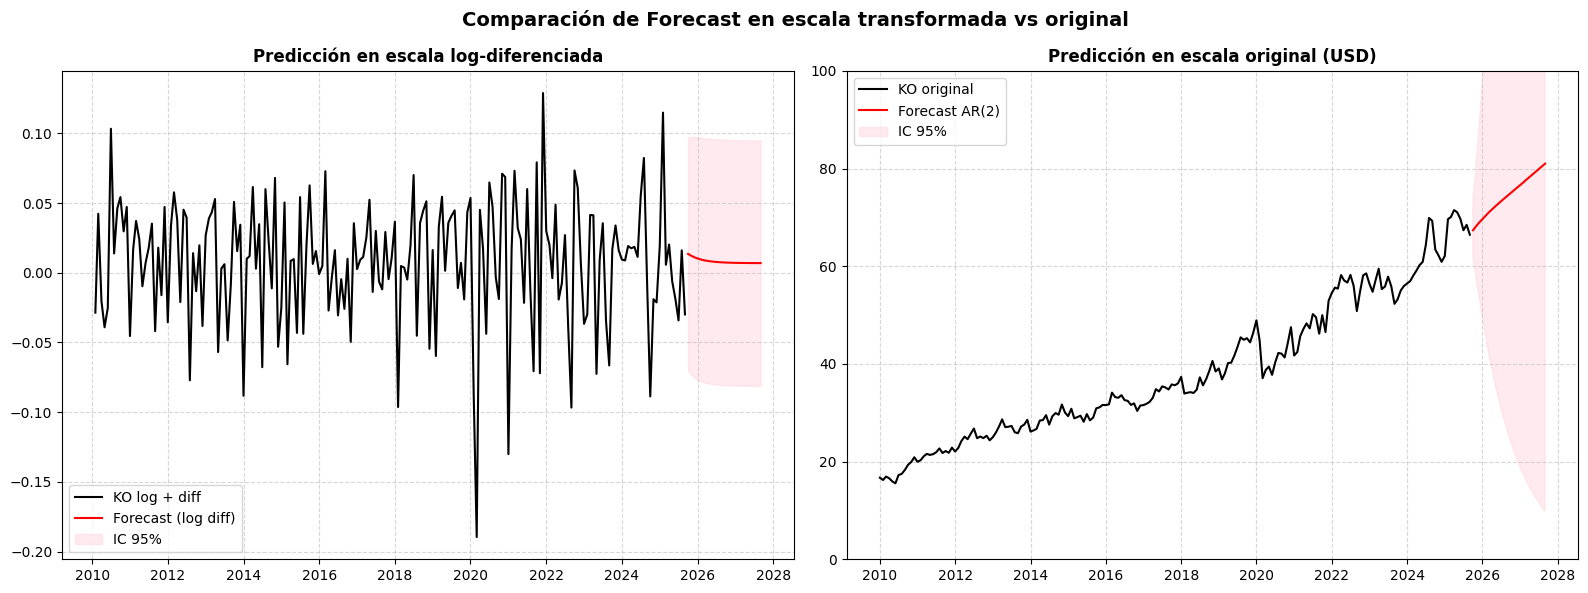

In [38]:
# ======================
# 4. Reconstrucción: de diff(log) → log → original
# ======================
last_log_value = ko_log.iloc[-1]  # último valor en log
forecast_log = forecast_diff_mean.cumsum() + last_log_value
forecast_original = np.exp(forecast_log)

forecast_log_ci = forecast_diff_ci.cumsum() + last_log_value
forecast_original_ci = np.exp(forecast_log_ci)

# ======================
# 5. Gráficos comparativos
# ======================
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# (a) Serie transformada: log + diff
axes[0].plot(ko_log_diff, label="KO log + diff", color="black")
axes[0].plot(forecast_diff_mean, label="Forecast (log diff)", color="red")
axes[0].fill_between(forecast_diff_ci.index, 
                     forecast_diff_ci.iloc[:,0], forecast_diff_ci.iloc[:,1],
                     color="pink", alpha=0.3, label="IC 95%")
axes[0].set_title("Predicción en escala log-diferenciada", fontsize=12, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# (b) Serie original
axes[1].plot(ko, label="KO original", color="black")
axes[1].plot(forecast_original, label="Forecast AR(2)", color="red")
axes[1].fill_between(forecast_original_ci.index, 
                     forecast_original_ci.iloc[:,0], forecast_original_ci.iloc[:,1],
                     color="pink", alpha=0.3, label="IC 95%")
axes[1].set_title("Predicción en escala original (USD)", fontsize=12, fontweight="bold")
axes[1].set_ylim(0, 100)  # 👈 recortar eje Y a máximo 100
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

plt.suptitle("Comparación de Forecast en escala transformada vs original", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Modelos $ARIMA(p,d,q)$

En esta clase de modelos se ajusta la diferenciación dentro del modelo, es decir, no es necesario hacer la diferenciación manualmente como lo hicimos en los ejemplos anteriores.

In [39]:
# ======================
# 5. Modelo ARIMA
# ======================
model_arima = ARIMA(ko_log, order=(1,1,1))  # d=1 porque diferenciamos dentro del modelo
result_arima = model_arima.fit()
print(result_arima.summary())


                               SARIMAX Results                                
Dep. Variable:                     KO   No. Observations:                  189
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 316.157
Date:                Wed, 24 Sep 2025   AIC                           -626.314
Time:                        19:22:03   BIC                           -616.604
Sample:                    01-01-2010   HQIC                          -622.380
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4214      0.413      1.020      0.308      -0.388       1.231
ma.L1         -0.5525      0.384     -1.438      0.150      -1.305       0.200
sigma2         0.0020      0.000     10.806      0.0

In [40]:
# ======================
# 3. Pronósticos directos con ARIMA sobre la serie original/log
# ======================
n_forecast = 24
forecast_arima = result_arima.get_forecast(steps=n_forecast)

forecast_mean = forecast_arima.predicted_mean
forecast_ci = forecast_arima.conf_int()

# Si ajustaste sobre log(ko) → forecast en log
# Convertir a original con exp()
forecast_original = np.exp(forecast_mean)
forecast_original_ci = np.exp(forecast_ci)


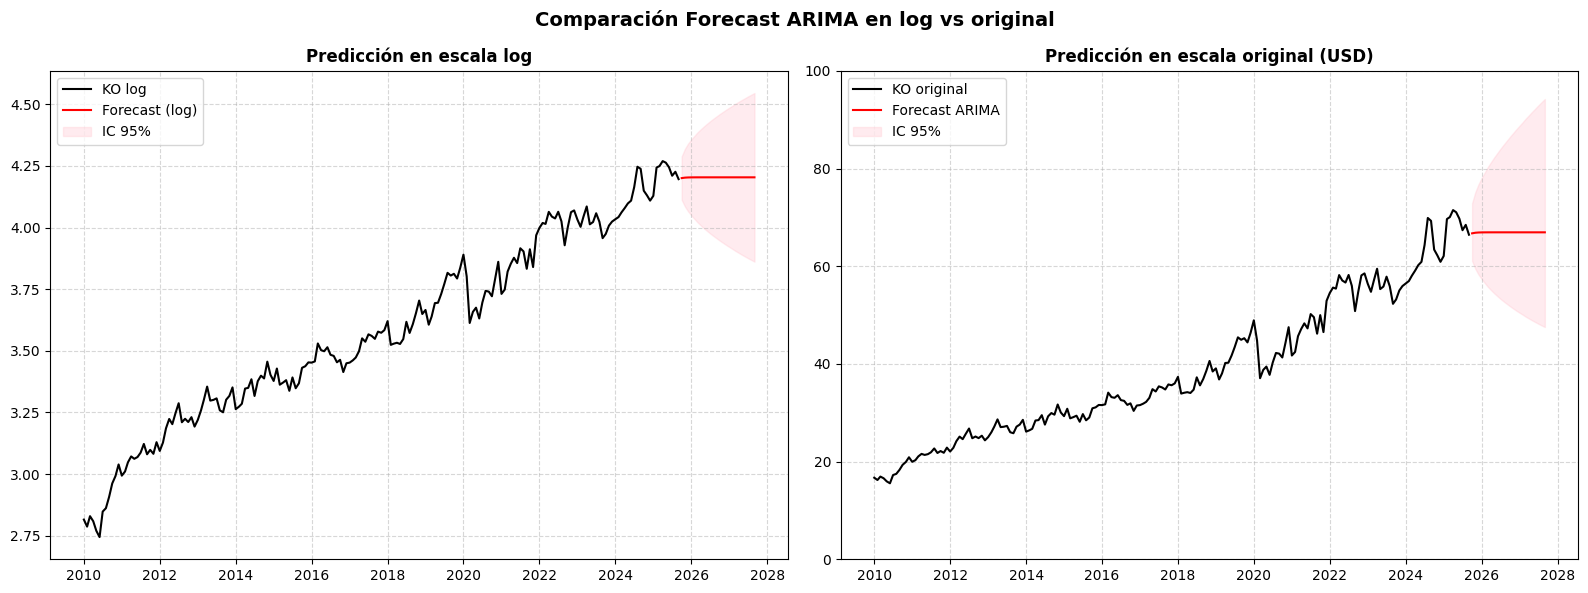

In [41]:

# ======================
# 4. Gráficos comparativos
# ======================
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# (a) Serie en log (modelo ajustado aquí)
axes[0].plot(ko_log, label="KO log", color="black")
axes[0].plot(forecast_mean, label="Forecast (log)", color="red")
axes[0].fill_between(forecast_ci.index, 
                     forecast_ci.iloc[:,0], forecast_ci.iloc[:,1],
                     color="pink", alpha=0.3, label="IC 95%")
axes[0].set_title("Predicción en escala log", fontsize=12, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# (b) Serie original en USD
axes[1].plot(ko, label="KO original", color="black")
axes[1].plot(forecast_original, label="Forecast ARIMA", color="red")
axes[1].fill_between(forecast_original_ci.index, 
                     forecast_original_ci.iloc[:,0], forecast_original_ci.iloc[:,1],
                     color="pink", alpha=0.3, label="IC 95%")
axes[1].set_title("Predicción en escala original (USD)", fontsize=12, fontweight="bold")
axes[1].set_ylim(0, 100)
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

plt.suptitle("Comparación Forecast ARIMA en log vs original", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [42]:
# ======================
# 6. Modelo SARIMA (estacional)
# ======================
model_sarima = SARIMAX(ko_log, 
                       order=(2,1,2), 
                       seasonal_order=(1,1,1,12))  # estacionalidad anual
result_sarima = model_sarima.fit()
print(result_sarima.summary())


                                      SARIMAX Results                                       
Dep. Variable:                                   KO   No. Observations:                  189
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                 289.323
Date:                              Wed, 24 Sep 2025   AIC                           -564.646
Time:                                      19:22:05   BIC                           -542.452
Sample:                                  01-01-2010   HQIC                          -555.644
                                       - 09-01-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1291      1.004     -0.129      0.898      -2.096       1.838
ar.L2          0.64

In [43]:
# ======================
# 3. Pronósticos directos con SARIMA sobre la serie original/log
# ======================
n_forecast = 24
forecast_sarima = result_sarima.get_forecast(steps=n_forecast)

forecast_mean = forecast_sarima.predicted_mean
forecast_ci = forecast_sarima.conf_int()

# Si ajustaste sobre log(ko) → forecast en log
# Convertir a original con exp()
forecast_original = np.exp(forecast_mean)
forecast_original_ci = np.exp(forecast_ci)


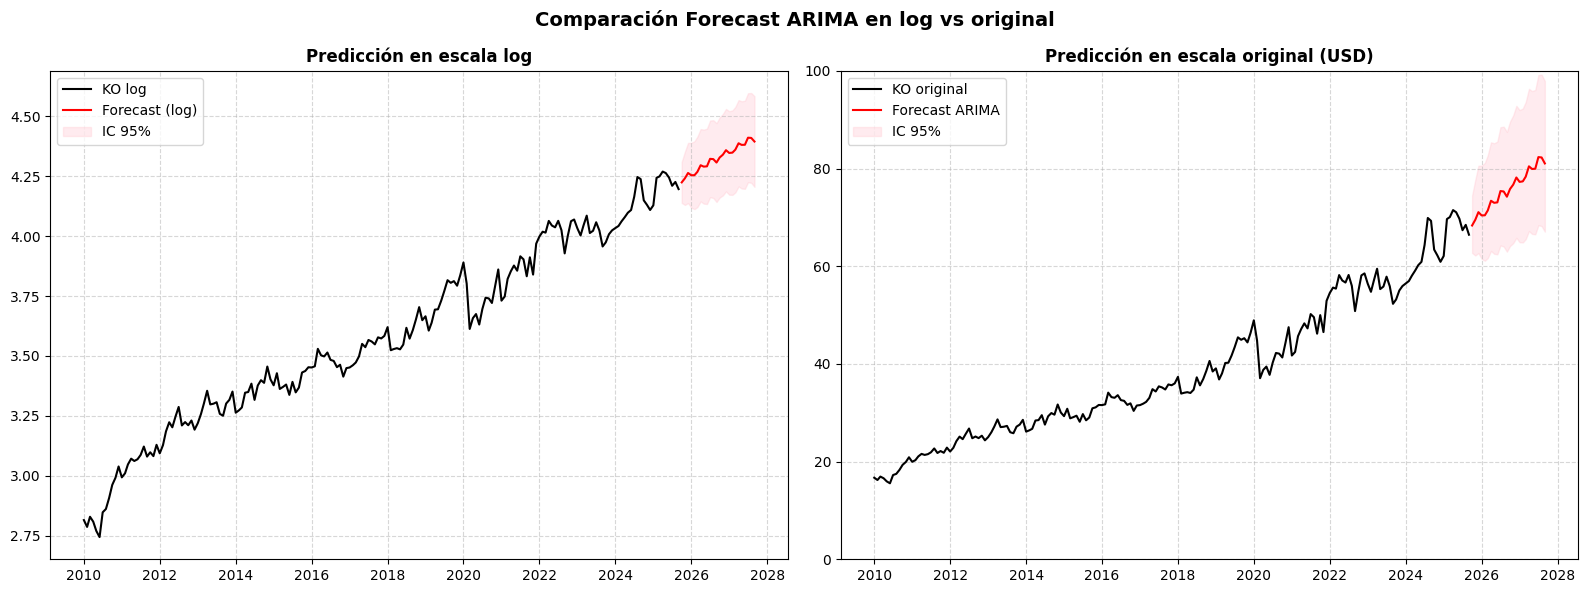

In [44]:

# ======================
# 4. Gráficos comparativos
# ======================
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# (a) Serie en log (modelo ajustado aquí)
axes[0].plot(ko_log, label="KO log", color="black")
axes[0].plot(forecast_mean, label="Forecast (log)", color="red")
axes[0].fill_between(forecast_ci.index, 
                     forecast_ci.iloc[:,0], forecast_ci.iloc[:,1],
                     color="pink", alpha=0.3, label="IC 95%")
axes[0].set_title("Predicción en escala log", fontsize=12, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# (b) Serie original en USD
axes[1].plot(ko, label="KO original", color="black")
axes[1].plot(forecast_original, label="Forecast ARIMA", color="red")
axes[1].fill_between(forecast_original_ci.index, 
                     forecast_original_ci.iloc[:,0], forecast_original_ci.iloc[:,1],
                     color="pink", alpha=0.3, label="IC 95%")
axes[1].set_title("Predicción en escala original (USD)", fontsize=12, fontweight="bold")
axes[1].set_ylim(0, 100)
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

plt.suptitle("Comparación Forecast ARIMA en log vs original", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [46]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in pdq]

best_aic = float("inf")
best_order = None
best_seasonal = None
best_model = None

for order in pdq:
    for s_order in seasonal_pdq:
        try:
            model = SARIMAX(ko_log, order=order, seasonal_order=s_order,
                            enforce_stationarity=False, enforce_invertibility=False)
            results = model.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = order
                best_seasonal = s_order
                best_model = results
        except:
            continue

print("✅ Mejor modelo encontrado:", best_order, "x", best_seasonal)
print("AIC:", best_aic)


✅ Mejor modelo encontrado: (2, 0, 1) x (0, 0, 0, 12)
AIC: -634.0605253157802


In [48]:
results_table = []

for order in pdq:
    try:
        model = ARIMA(ko_log, order=order)
        res = model.fit()
        results_table.append({
            "Modelo": f"ARIMA{order}",
            "AIC": res.aic,
            "BIC": res.bic,
            "LogLik": res.llf
        })
    except:
        continue

summary_df = pd.DataFrame(results_table).sort_values("AIC").reset_index(drop=True)

print("📊 Tabla comparativa de modelos ARIMA")
summary_df

📊 Tabla comparativa de modelos ARIMA


,Modelo,AIC,BIC,LogLik
0,"ARIMA(2, 1, 2)",-629.419770,-613.237561,319.709885
1,"ARIMA(2, 1, 0)",-627.957260,-618.247934,316.978630
2,"ARIMA(0, 1, 2)",-627.566046,-617.856720,316.783023
3,"ARIMA(0, 1, 1)",-626.933112,-620.460228,315.466556
4,"ARIMA(0, 1, 0)",-626.418233,-623.181791,314.209117
5,"ARIMA(1, 1, 1)",-626.313800,-616.604474,316.156900
6,"ARIMA(1, 1, 0)",-626.289362,-619.816478,315.144681
7,"ARIMA(2, 1, 1)",-626.051873,-613.106105,317.025936
8,"ARIMA(1, 1, 2)",-625.833274,-612.887507,316.916637
9,"ARIMA(2, 2, 1)",-624.466175,-611.541741,316.233088


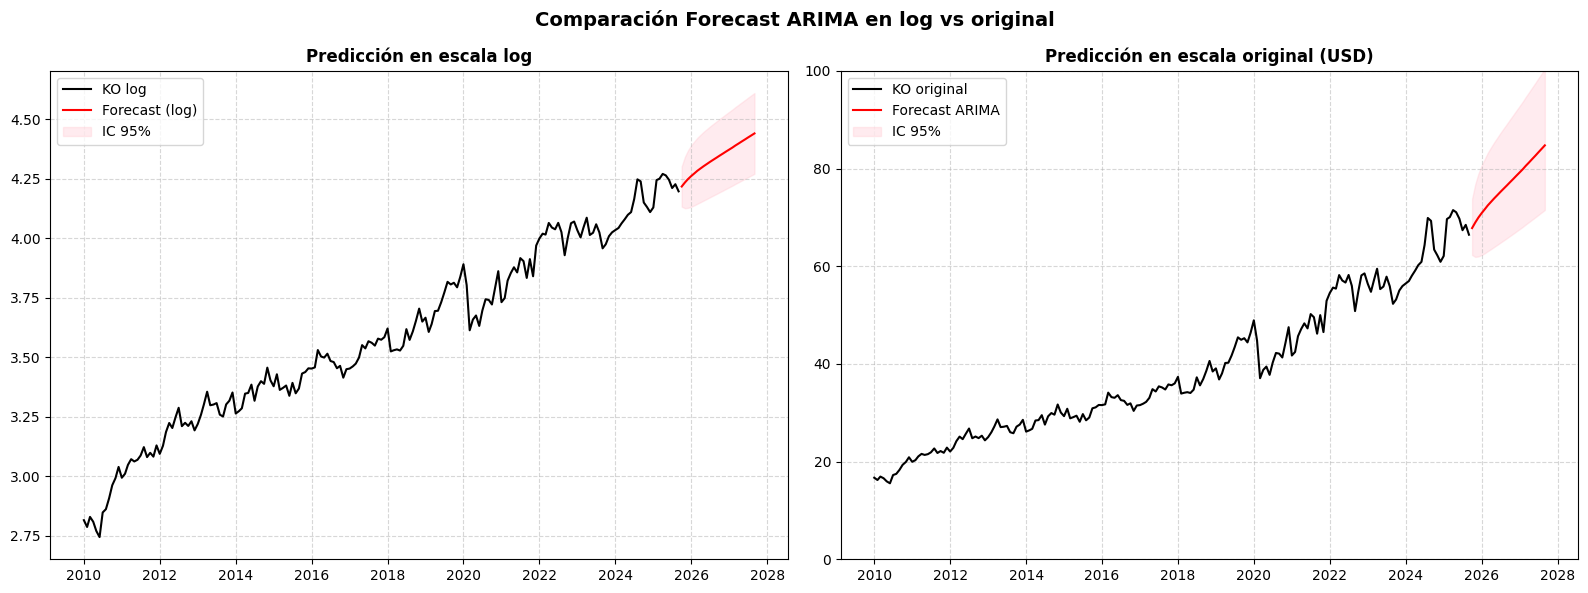

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 1. Forecast en log
# ======================
n_periods = 24  # horizonte de predicción (24 meses)
forecast_res = best_model.get_forecast(steps=n_periods)

forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

# ======================
# 2. Transformación a escala original (USD)
# ======================
forecast_original = np.exp(forecast_mean)
forecast_original_ci = np.exp(forecast_ci)

# ======================
# 3. Gráficos comparativos
# ======================
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# (a) Serie en log (modelo ajustado aquí)
axes[0].plot(ko_log, label="KO log", color="black")
axes[0].plot(forecast_mean, label="Forecast (log)", color="red")
axes[0].fill_between(forecast_ci.index, 
                     forecast_ci.iloc[:,0], forecast_ci.iloc[:,1],
                     color="pink", alpha=0.3, label="IC 95%")
axes[0].set_title("Predicción en escala log", fontsize=12, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# (b) Serie original en USD
axes[1].plot(ko, label="KO original", color="black")
axes[1].plot(forecast_original, label="Forecast ARIMA", color="red")
axes[1].fill_between(forecast_original_ci.index, 
                     forecast_original_ci.iloc[:,0], forecast_original_ci.iloc[:,1],
                     color="pink", alpha=0.3, label="IC 95%")
axes[1].set_title("Predicción en escala original (USD)", fontsize=12, fontweight="bold")
axes[1].set_ylim(0, 100)  # para que quede visualmente claro
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

plt.suptitle("Comparación Forecast ARIMA en log vs original", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Ejemplo bonito donde funcionan bien los modelos

Los datos que vamos a utilizar corresponden al consumo de energía eléctrica por hora de PJM.
El consumo de energía tiene algunas características particulares, y será interesante ver cómo SARIMA los calcula.

Estamos extrayendo la información de PJM East, que contiene datos desde 2002 hasta 2018 para toda la región este.

In [53]:
df_electric = pd.read_csv("AEP_hourly.csv", index_col=0, parse_dates=True)
# Asegurar que el índice es datetime
df_electric.index = pd.to_datetime(df_electric.index)

In [54]:
df_electric.head()

,AEP_MW
Datetime,
2004-12-31 01:00:00,13478.0
2004-12-31 02:00:00,12865.0
2004-12-31 03:00:00,12577.0
2004-12-31 04:00:00,12517.0
2004-12-31 05:00:00,12670.0


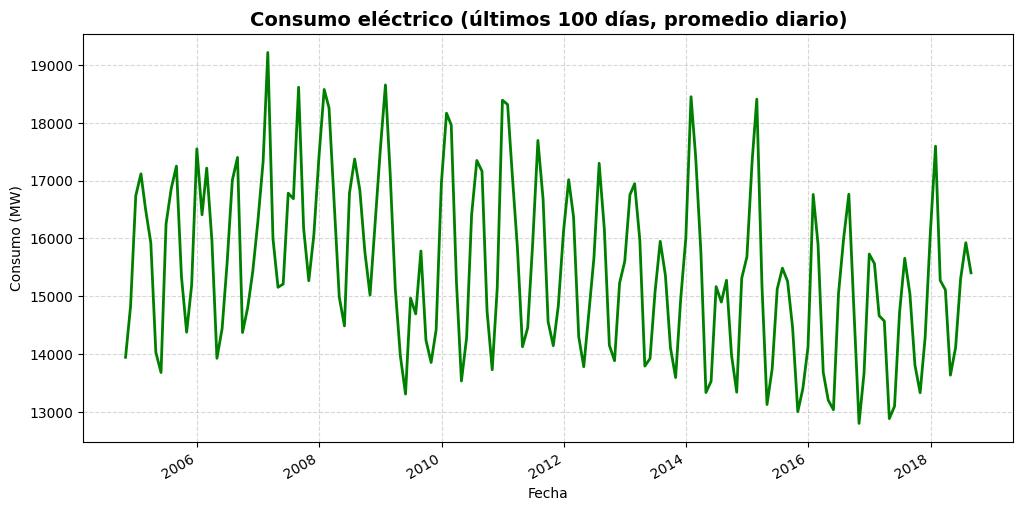

In [60]:
daily = df_electric["AEP_MW"].resample("M").mean()

last_100_months = daily.tail(200)

plt.figure(figsize=(12,6))
plt.plot(last_100_months.index, last_100_months, linewidth=2, color="green")
plt.title("Consumo eléctrico (últimos 100 días, promedio diario)", fontsize=14, fontweight="bold")
plt.xlabel("Fecha")
plt.ylabel("Consumo (MW)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.gcf().autofmt_xdate()
plt.show()

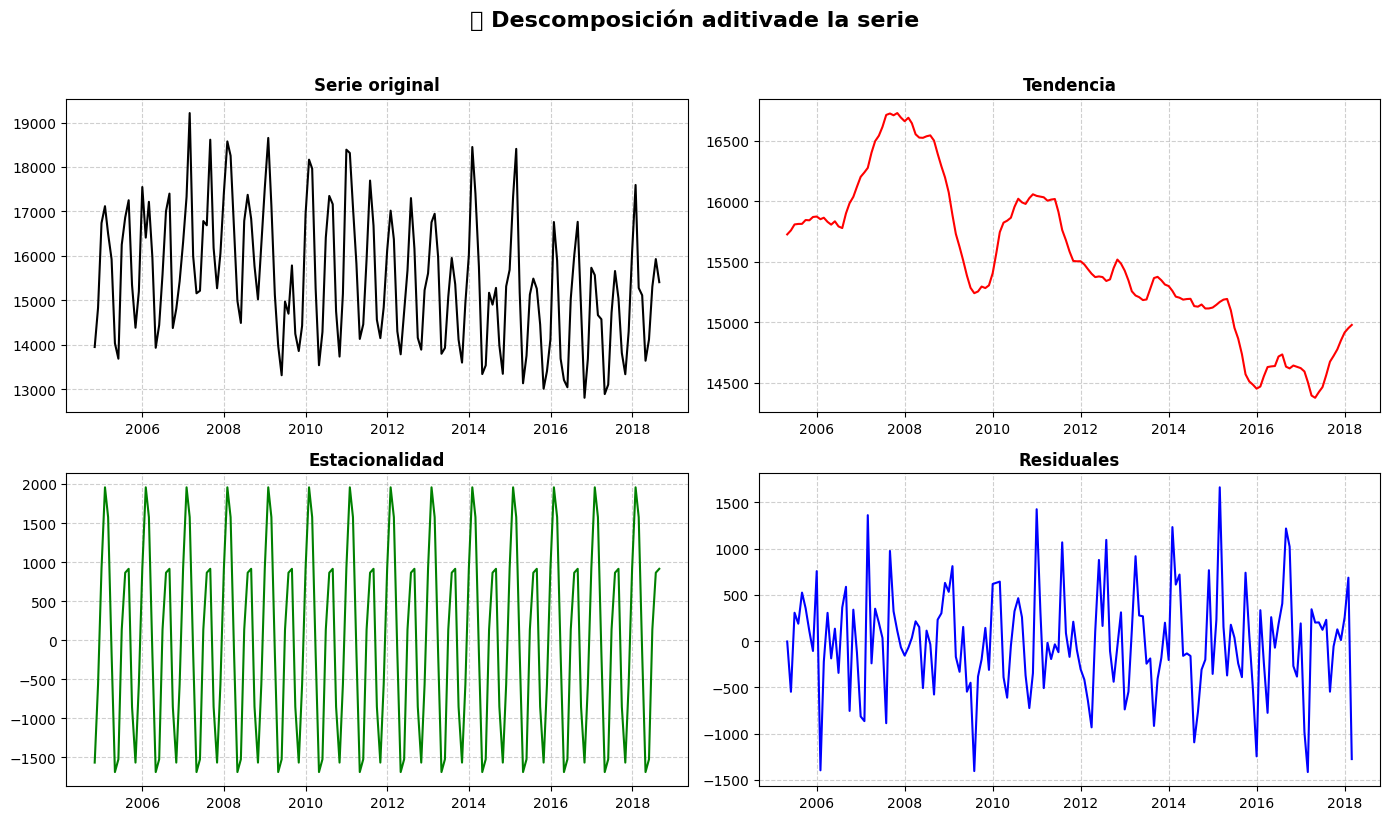

In [66]:
decomp = seasonal_decompose(last_100_months, model="additive", period=12)  

# Crear figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Serie original
axes[0,0].plot(last_100_months, color="black")
axes[0,0].set_title("Serie original", fontsize=12, fontweight="bold")

# Tendencia
axes[0,1].plot(decomp.trend, color="red")
axes[0,1].set_title("Tendencia", fontsize=12, fontweight="bold")

# Estacionalidad
axes[1,0].plot(decomp.seasonal, color="green")
axes[1,0].set_title("Estacionalidad", fontsize=12, fontweight="bold")

# Residuales
axes[1,1].plot(decomp.resid, color="blue")
axes[1,1].set_title("Residuales", fontsize=12, fontweight="bold")

# Ajustes estéticos
for ax in axes.flat:
    ax.grid(True, linestyle="--", alpha=0.6)

plt.suptitle("📊 Descomposición aditivade la serie", 
             fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

### 📊 Evaluación de estacionariedad en datos eléctricos

En este ejemplo vamos a diagnosticar si la serie es estacionaria, evaluando:

1. Media constante (ADF / KPSS).  
2. Varianza constante (ARCH test).  
3. Covarianza dependiente solo del rezago (ACF/PACF).  
4. Residuales como ruido blanco (Ljung-Box).  

In [62]:
from statsmodels.tsa.stattools import adfuller, kpss

# Augmented Dickey-Fuller Test
adf_result = adfuller(last_100_months)

print("ADF Test")
print("H0 = Serie no estacionaria")
print(f"Estadístico: {adf_result[0]:.4f}, p-value: {adf_result[1]:.4f}")


ADF Test
H0 = Serie no estacionaria
Estadístico: -1.6960, p-value: 0.4332


In [63]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(last_100_months)
print("ARCH Test")
print("H0 = varianza constante")
print(f"Estadístico: {arch_test[0]:.4f}, p-value: {arch_test[1]:.4f}")

ARCH Test
H0 = varianza constante
Estadístico: 112.3261, p-value: 0.0000


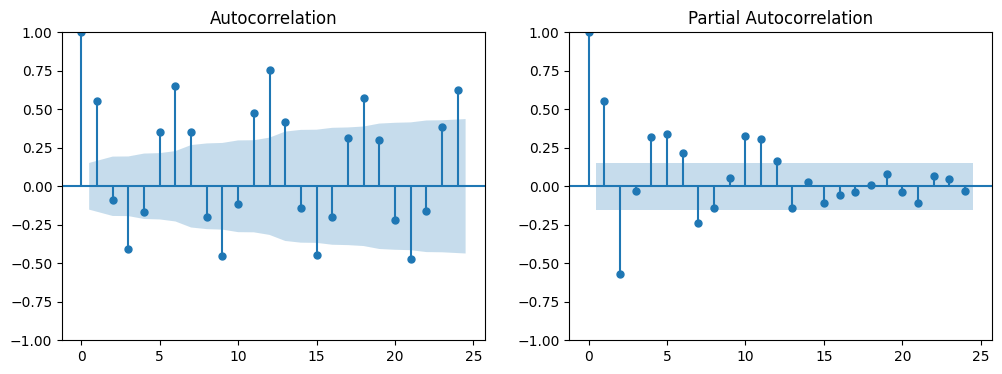

In [64]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(last_100_months, lags=24, ax=axes[0])
plot_pacf(last_100_months, lags=24, ax=axes[1])
plt.show()

In [65]:
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in pdq]

best_aic = float("inf")
best_order = None
best_seasonal = None
best_model = None

for order in pdq:
    for s_order in seasonal_pdq:
        try:
            model = SARIMAX(last_100_months, order=order, seasonal_order=s_order,
                            enforce_stationarity=False, enforce_invertibility=False)
            results = model.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = order
                best_seasonal = s_order
                best_model = results
        except:
            continue

print("✅ Mejor modelo encontrado:", best_order, "x", best_seasonal)
print("AIC:", best_aic)


✅ Mejor modelo encontrado: (0, 2, 2) x (0, 2, 2, 12)
AIC: 1873.7970386750574


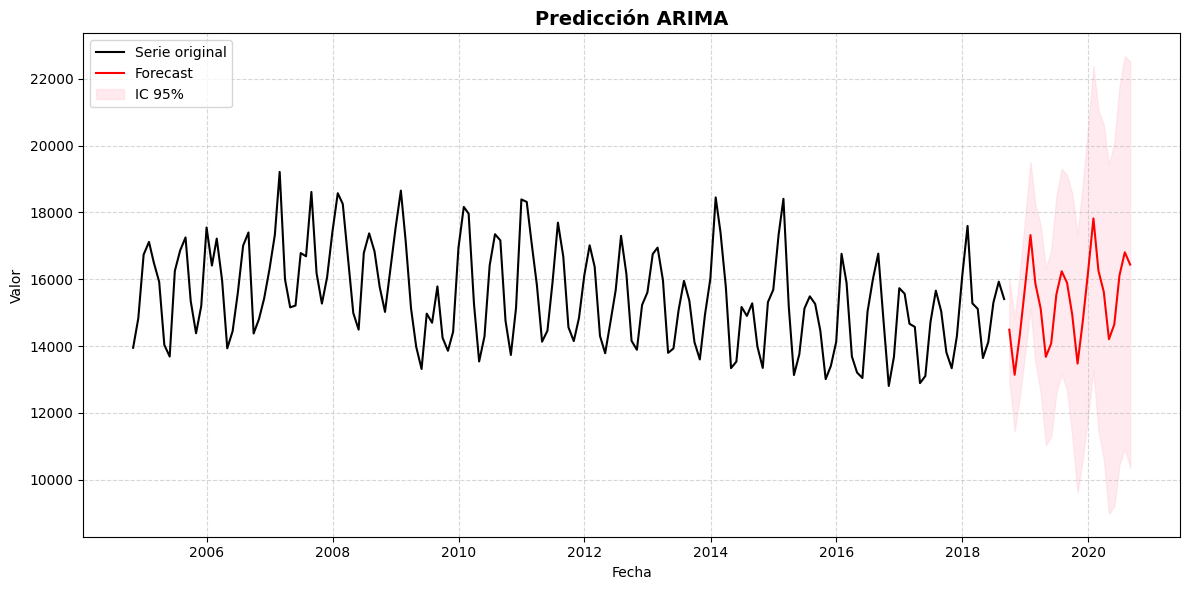

In [70]:
n_periods = 24  # horizonte de predicción (24 meses)
forecast_res = best_model.get_forecast(steps=n_periods)

forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

# ======================
# 2. Transformación a escala original
# ======================
forecast_original = np.exp(forecast_mean)
forecast_original_ci = np.exp(forecast_ci)

# ======================
# 3. Gráficos comparativos
# ======================
plt.figure(figsize=(12,6))

plt.plot(last_100_months, label="Serie original", color="black")
plt.plot(forecast_mean, label="Forecast", color="red")
plt.fill_between(forecast_ci.index, 
                 forecast_ci.iloc[:,0], forecast_ci.iloc[:,1],
                 color="pink", alpha=0.3, label="IC 95%")

plt.title("Predicción ARIMA", fontsize=14, fontweight="bold")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()